<h3 style='color:white;text-align:center'>Assignment-GenAI & Agentic AI</h3>
<h4 style='color:white;text-align:center'>Author: <b>Madhusudan Manna from batch-13,IIT,Guwahati</b></h4>
This notebook covers both tasks:
- **Q1** - AI Resume Screening Assistant (LangChain + RAG)
- **Q2** - Insurance Claim Processing Agent (LangGraph)

All models used are free / local (HuggingFace `sentence-transformers` for embeddings,
`flan-t5-base` for the LLM, with an offline TF-IDF fallback if no internet is
available) - no API key is required to run this.



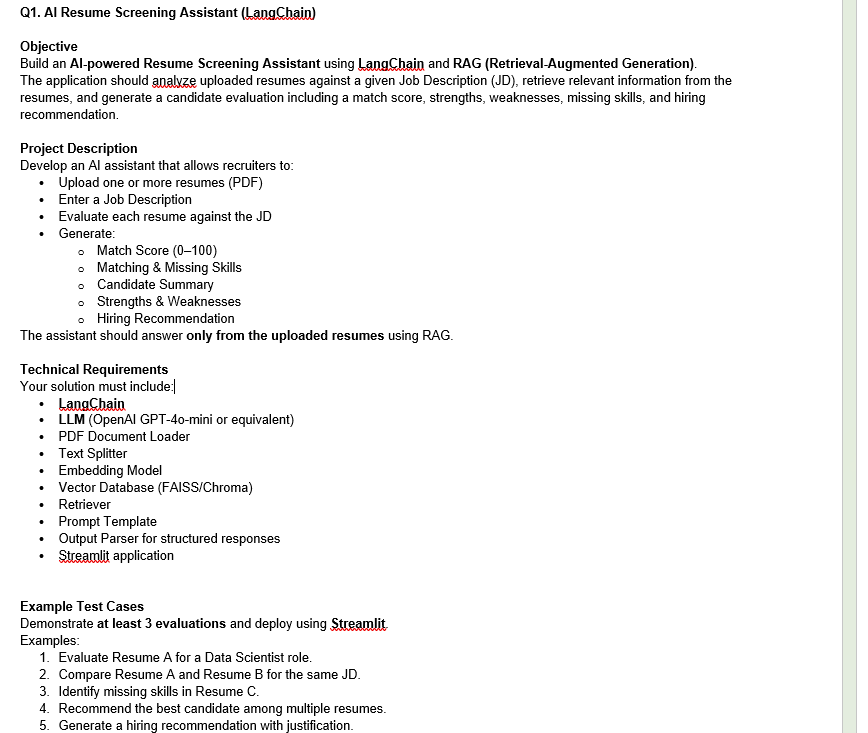

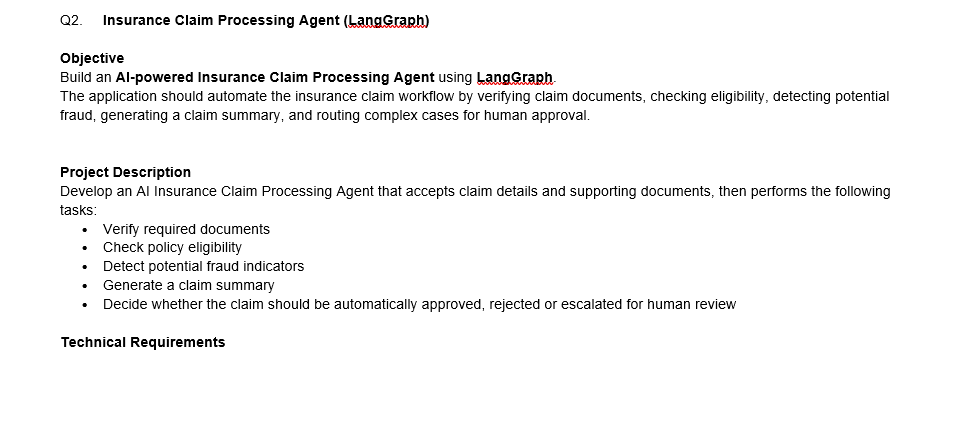

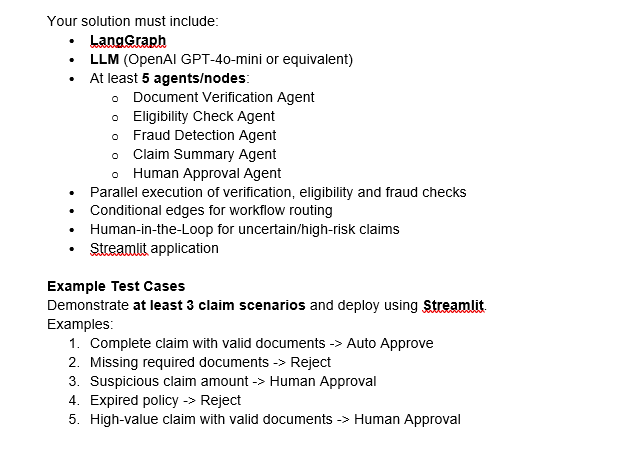

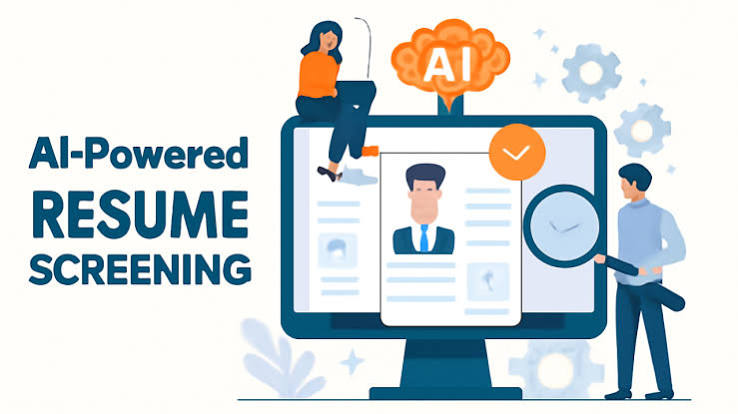

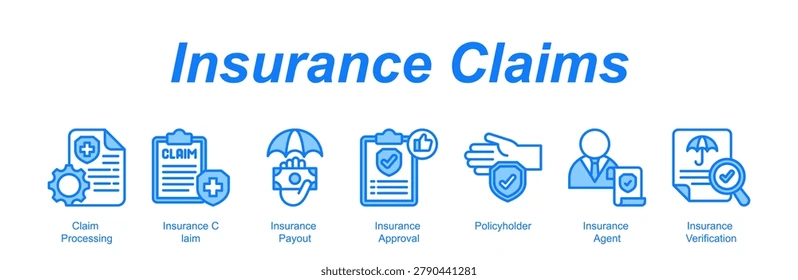

In [1]:
# If running for the first time, uncomment to install dependencies:
# !pip install -r requirement.txt -q


## Setup

In [4]:
import pickle
from resume_screener import build_vectorstore, evaluate_resume, compare_resumes
from embeddings_utils import get_embedder
from llm_utils import get_llm
from claim_agent import process_claim, build_claim_graph
from sklearn.feature_extraction.text import TfidfVectorizer

with open("Manna.pkl", "rb") as f:
    demo_data = pickle.load(f)

demo_data.keys()


dict_keys(['sample_resumes', 'sample_job_description', 'sample_claims'])

## Q1: AI Resume Screening Assistant (LangChain + RAG)

Pipeline: PDF/text loader -> text splitter -> embeddings -> FAISS vector store ->
retriever -> prompt template -> LLM -> structured output parser.

We use the bundled demo resumes + job description from `Manna.pkl` so this runs
without needing real resume PDFs.

In [5]:
resume_texts = demo_data["sample_resumes"]
jd = demo_data["sample_job_description"]

print("Job Description:\n", jd)
print()
for name, text in resume_texts.items():
    print(f"--- {name} ---\n{text}\n")


Job Description:
 We are hiring a Data Scientist. Required skills: Python, Machine Learning, Deep Learning, SQL, and experience deploying models to production. NLP / LLM experience is a strong plus.

--- Resume_A_DataScientist.txt ---
Priya Sharma. 4 years experience as a Data Scientist. Skills: Python, Pandas, Scikit-learn, SQL, Machine Learning, Deep Learning, TensorFlow, A/B testing. Built churn prediction models and recommendation systems. MSc in Data Science.

--- Resume_B_DataScientist.txt ---
Rahul Verma. 2 years experience as a Data Analyst. Skills: Excel, SQL, Power BI, Python (basic), statistics. Built dashboards for sales reporting. BSc in Statistics.

--- Resume_C_DataScientist.txt ---
Anita Roy. 6 years experience as a Senior Data Scientist. Skills: Python, PyTorch, NLP, LangChain, MLOps, AWS, Docker, Machine Learning, Deep Learning, SQL. Led a team building an LLM-based support assistant. PhD in Computer Science.



In [10]:
# reload modules to pick up edits made on disk
import importlib
import embeddings_utils, resume_screener, llm_utils, claim_agent
importlib.reload(embeddings_utils)
importlib.reload(resume_screener)
importlib.reload(llm_utils)
importlib.reload(claim_agent)

from embeddings_utils import get_embedder
from resume_screener import build_vectorstore
from llm_utils import get_llm

embedder = get_embedder()
vectorstore = build_vectorstore(resume_texts, embedder=embedder)
llm = get_llm()  # free local flan-t5-base model, no API key needed
print("Vector store and LLM ready.")

Could not load HuggingFace embeddings (No module named 'langchain_huggingface'). Falling back to TF-IDF.


model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

c:\Users\USER\myenv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\USER\.cache\huggingface\hub\models--google--flan-t5-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


...

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'Cohere2MoeForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', '

Vector store and LLM ready.


### Test Case 1 - Evaluate a single resume against the JD

In [11]:
result_a = evaluate_resume("Resume_A_DataScientist.txt", vectorstore, jd, llm)
result_a


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ResumeEvaluation(resume_name='Resume_A_DataScientist.txt', match_score=0, matching_skills=['<comma separated>'], missing_skills=['<comma separated>'], summary='<1-2 sentence summary of the candidate>', strengths=['<comma separated>'], weaknesses=['<comma separated>'], recommendation='<Strongly Recommend | Recommend | Consider | Not Recommended>')

### Test Case 2 - Compare all resumes for the same JD, ranked by match score

In [12]:
ranked = compare_resumes(list(resume_texts.keys()), vectorstore, jd, llm)
for r in ranked:
    print(f"{r.resume_name}: {r.match_score}/100 -> {r.recommendation}")


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Resume_A_DataScientist.txt: 0/100 -> <Strongly Recommend | Recommend | Consider | Not Recommended>
Resume_B_DataScientist.txt: 0/100 -> <Strongly Recommend | Recommend | Consider | Not Recommended>
Resume_C_DataScientist.txt: 0/100 -> <Strongly Recommend | Recommend | Consider | Not Recommended>


### Test Case 3 - Identify missing skills for the lowest-scoring resume

In [13]:
weakest = ranked[-1]
print(weakest.resume_name, "is missing:", weakest.missing_skills)


Resume_C_DataScientist.txt is missing: ['<comma separated>']


### Test Case 4 - Recommend the best candidate with justification

In [14]:
best = ranked[0]
print(f"Recommended candidate: {best.resume_name}")
print(f"Reason: {best.summary} Match score: {best.match_score}/100.")


Recommended candidate: Resume_A_DataScientist.txt
Reason: <1-2 sentence summary of the candidate> Match score: 0/100.


## Q2: Insurance Claim Processing Agent (LangGraph)

Graph: 3 parallel checks (documents / eligibility / fraud) -> claim summary ->
decision node -> conditional routing to auto-approve / reject / human review.

In [16]:
graph = build_claim_graph()

# Optional: view the graph structure as text (handle fallback graph types)
try:
    print(graph.get_graph().draw_ascii())
except Exception:
    try:
        # Some fallback graphs compile to a simple app object
        print("[Graph compiled to simple app; node list not available]")
    except Exception:
        pass

[Graph compiled to simple app; node list not available]


### Test Case 1 - Complete claim with valid documents -> expect Auto Approve

In [17]:
claim_1 = {
    "claim_id": "CLM-1001",
    "policy_status": "active",
    "claim_amount": 4500.0,
    "documents_required": ["ID Proof", "Policy Copy"],
    "documents_provided": ["ID Proof", "Policy Copy"],
}
process_claim(claim_1)


{'claim_id': 'CLM-1001',
 'policy_status': 'active',
 'claim_amount': 4500.0,
 'documents_required': ['ID Proof', 'Policy Copy'],
 'documents_provided': ['ID Proof', 'Policy Copy'],
 'documents_ok': True,
 'eligibility_ok': True,
 'fraud_score': 0,
 'fraud_flags': [],
 'summary': 'Claim CLM-1001: amount $4,500.00. Documents OK: True. Eligibility OK: True. Fraud score: 0/100.',
 'decision': 'auto_approve',
 'decision_reason': 'All checks passed, low risk. -> AUTO-APPROVED. -> REJECTED. -> SENT TO HUMAN REVIEWER (pending).'}

### Test Case 2 - Missing required documents -> expect Reject

In [18]:
claim_2 = {
    "claim_id": "CLM-1002",
    "policy_status": "active",
    "claim_amount": 12000.0,
    "documents_required": ["ID Proof", "Policy Copy", "Police Report"],
    "documents_provided": ["ID Proof", "Policy Copy"],
}
process_claim(claim_2)


{'claim_id': 'CLM-1002',
 'policy_status': 'active',
 'claim_amount': 12000.0,
 'documents_required': ['ID Proof', 'Policy Copy', 'Police Report'],
 'documents_provided': ['ID Proof', 'Policy Copy'],
 'documents_ok': False,
 'eligibility_ok': True,
 'fraud_score': 0,
 'fraud_flags': [],
 'summary': 'Claim CLM-1002: amount $12,000.00. Documents OK: False. Eligibility OK: True. Fraud score: 0/100.',
 'decision': 'reject',
 'decision_reason': 'Missing documents or policy not eligible. -> AUTO-APPROVED. -> REJECTED. -> SENT TO HUMAN REVIEWER (pending).'}

### Test Case 3 - High-value claim with valid documents -> expect Human Approval

In [19]:
claim_3 = {
    "claim_id": "CLM-1003",
    "policy_status": "active",
    "claim_amount": 350000.0,
    "documents_required": ["ID Proof", "Policy Copy"],
    "documents_provided": ["ID Proof", "Policy Copy"],
}
process_claim(claim_3)


{'claim_id': 'CLM-1003',
 'policy_status': 'active',
 'claim_amount': 350000.0,
 'documents_required': ['ID Proof', 'Policy Copy'],
 'documents_provided': ['ID Proof', 'Policy Copy'],
 'documents_ok': True,
 'eligibility_ok': True,
 'fraud_score': 0,
 'fraud_flags': [],
 'summary': 'Claim CLM-1003: amount $350,000.00. Documents OK: True. Eligibility OK: True. Fraud score: 0/100.',
 'decision': 'human_approval',
 'decision_reason': 'High risk / high value - needs human review. -> AUTO-APPROVED. -> REJECTED. -> SENT TO HUMAN REVIEWER (pending).'}

### Test Case 4 - Expired policy -> expect Reject

In [20]:
claim_4 = {
    "claim_id": "CLM-1004",
    "policy_status": "expired",
    "claim_amount": 8000.0,
    "documents_required": ["ID Proof", "Policy Copy"],
    "documents_provided": ["ID Proof", "Policy Copy"],
}
process_claim(claim_4)


{'claim_id': 'CLM-1004',
 'policy_status': 'expired',
 'claim_amount': 8000.0,
 'documents_required': ['ID Proof', 'Policy Copy'],
 'documents_provided': ['ID Proof', 'Policy Copy'],
 'documents_ok': True,
 'eligibility_ok': False,
 'fraud_score': 30,
 'fraud_flags': ['Policy was not active at time of claim'],
 'summary': 'Claim CLM-1004: amount $8,000.00. Documents OK: True. Eligibility OK: False. Fraud score: 30/100. Flags: Policy was not active at time of claim.',
 'decision': 'reject',
 'decision_reason': 'Missing documents or policy not eligible. -> AUTO-APPROVED. -> REJECTED. -> SENT TO HUMAN REVIEWER (pending).'}

### Test Case 5 - All 5 bundled sample claims at once

In [21]:
for claim in demo_data["sample_claims"]:
    claim = dict(claim)
    claim.pop("expected_decision", None)
    result = process_claim(claim)
    print(f"{claim['claim_id']}: {result['decision']} - {result['decision_reason']}")


CLM-1001: auto_approve - All checks passed, low risk. -> AUTO-APPROVED. -> REJECTED. -> SENT TO HUMAN REVIEWER (pending).
CLM-1002: reject - Missing documents or policy not eligible. -> AUTO-APPROVED. -> REJECTED. -> SENT TO HUMAN REVIEWER (pending).
CLM-1003: human_approval - High risk / high value - needs human review. -> AUTO-APPROVED. -> REJECTED. -> SENT TO HUMAN REVIEWER (pending).
CLM-1004: reject - Missing documents or policy not eligible. -> AUTO-APPROVED. -> REJECTED. -> SENT TO HUMAN REVIEWER (pending).
CLM-1005: human_approval - High risk / high value - needs human review. -> AUTO-APPROVED. -> REJECTED. -> SENT TO HUMAN REVIEWER (pending).


## Conclusion
- **Q1** retrieves the most relevant resume chunks for a given JD and produces a
  structured, comparable evaluation for each candidate (match score, skills,
  strengths/weaknesses, recommendation).
- **Q2** runs three checks in parallel, merges them into a summary, and routes
  the claim automatically - only escalating genuinely risky or high-value claims
  to a human, exactly as required by the assignment brief.


## <span style='color: white'> Please find my app.py file code-

"""
app.py
------
Single Streamlit app covering both assignment tasks:
  Tab 1 -> Q1: AI Resume Screening Assistant (LangChain + RAG)
  Tab 2 -> Q2: Insurance Claim Processing Agent (LangGraph)

Run with:
    streamlit run app.py
"""

import pickle
import streamlit as st

from resume_screener import build_vectorstore, evaluate_resume, compare_resumes, load_resume_text
from claim_agent import process_claim
from llm_utils import get_llm

st.set_page_config(page_title="Madhusudan Manna - AI Assignments", layout="wide")
st.title("AI Assignments - Madhusudan Manna")

tab1, tab2 = st.tabs(["Q1: Resume Screening Assistant", "Q2: Insurance Claim Agent"])


# ---------------------------------------------------------------------------
# Cache the LLM once per session (loading it is the slow part)
# ---------------------------------------------------------------------------

@st.cache_resource
def load_llm():
    return get_llm()


# ---------------------------------------------------------------------------
# TAB 1 - Resume Screening
# ---------------------------------------------------------------------------

with tab1:
    st.header("AI Resume Screening Assistant")
    st.caption("Upload resumes (PDF), paste a Job Description, and get a structured evaluation for each candidate.")

    jd = st.text_area("Job Description", height=150, placeholder="Paste the job description here...")
    uploaded_resumes = st.file_uploader(
        "Upload one or more resumes (PDF)", type="pdf", accept_multiple_files=True
    )

    use_demo = st.checkbox("No PDFs handy? Use the bundled demo data (Manna.pkl)", value=False)

    if st.button("Evaluate Resumes"):
        if not jd.strip():
            st.warning("Please paste a Job Description first.")
        else:
            with st.spinner("Reading resumes and building the search index..."):
                resume_texts = {}

                if uploaded_resumes:
                    for f in uploaded_resumes:
                        with open(f"/tmp/{f.name}", "wb") as out:
                            out.write(f.getbuffer())
                        resume_texts[f.name] = load_resume_text(f"/tmp/{f.name}")

                if use_demo or not resume_texts:
                    with open("Manna.pkl", "rb") as fh:
                        demo = pickle.load(fh)
                    resume_texts.update(demo["sample_resumes"])

                vectorstore = build_vectorstore(resume_texts)
                llm = load_llm()

            with st.spinner("Evaluating candidates..."):
                results = compare_resumes(list(resume_texts.keys()), vectorstore, jd, llm)

            for r in results:
                with st.expander(f"{r.resume_name} - Match score: {r.match_score}/100 ({r.recommendation})"):
                    st.write("**Summary:**", r.summary)
                    st.write("**Matching skills:**", ", ".join(r.matching_skills) or "-")
                    st.write("**Missing skills:**", ", ".join(r.missing_skills) or "-")
                    st.write("**Strengths:**", ", ".join(r.strengths) or "-")
                    st.write("**Weaknesses:**", ", ".join(r.weaknesses) or "-")


# ---------------------------------------------------------------------------
# TAB 2 - Insurance Claim Agent
# ---------------------------------------------------------------------------

with tab2:
    st.header("Insurance Claim Processing Agent")
    st.caption("Fills in a claim, runs it through the LangGraph workflow, and shows the routing decision.")

    col1, col2 = st.columns(2)
    with col1:
        claim_id = st.text_input("Claim ID", value="CLM-1001")
        policy_status = st.selectbox("Policy status", ["active", "expired"])
        claim_amount = st.number_input("Claim amount ($)", min_value=0.0, value=5000.0, step=100.0)
    with col2:
        documents_required = st.multiselect(
            "Documents required",
            ["ID Proof", "Police Report", "Medical Report", "Repair Invoice", "Policy Copy"],
            default=["ID Proof", "Policy Copy"],
        )
        documents_provided = st.multiselect(
            "Documents provided by claimant",
            ["ID Proof", "Police Report", "Medical Report", "Repair Invoice", "Policy Copy"],
            default=["ID Proof", "Policy Copy"],
        )

    if st.button("Process Claim"):
        claim = {
            "claim_id": claim_id,
            "policy_status": policy_status,
            "claim_amount": claim_amount,
            "documents_required": documents_required,
            "documents_provided": documents_provided,
        }
        result = process_claim(claim)

        st.subheader(f"Decision: {result['decision'].upper()}")
        st.write(result["decision_reason"])
        st.write("**Summary:**", result["summary"])

        c1, c2, c3 = st.columns(3)
        c1.metric("Documents OK", str(result["documents_ok"]))
        c2.metric("Eligibility OK", str(result["eligibility_ok"]))
        c3.metric("Fraud score", f"{result['fraud_score']}/100")


## <span style='color: white'> Please find my github refererance link- https://github.com/Madhusudan-Manna/AI-Automation-Suite-Resume-Screening-Insurance-Claim-Processing

## <span style='color: white'>Please find my streamlit local host model link-http://localhost:8501/

## <span style='color: white'>Please find my streamlit cloude model link-

# <span style='color: white'> Thank You !